---
authors:
  - name: Francesca Drummer
  - name: Philipp Sven Lars Schäfer
  - name: Daniel Dimitrov
---

# Cell-cell communication in spatial transcriptomics

<div style="border: 2px solid #c1121f; padding: 15px; border-radius: 8px;">
<ul style="margin-top: 10px; padding-left: 25px; font-size: 17px; color: #c1121f; list-style-type: none; font-weight: bold;">
<li>This notebook is part of a community effort from a guide for imaging-based spatial transcriptomics analysis in the Theislab led by Sara Jimenez and Francesca Drummer (unpublished). It will be integrated into the <a href="https://www.sc-best-practices.org/" target="_blank" style="color: #c1121f; text-decoration: underline;">sc-best-practices guide</a> appending the spatial omics chapters.</li>
<li style="margin-top: 10px;">Authors of this notebook: Francesca Drummer (Theislab @ Helmholtz Munich), Philipp Sven Lars Schäfer (Saezlab @ EMBL), Daniel Dimitrov (Steglelab @ EMBL).</li>
</ul>
</div>

## Background and motivation

Cell-cell communication (CCC) orchestrates multicellular life, supporting processes such as development, immunity, and tissue homeostasis; consequently, its dysregulation contributes to a wide range of conditions.
Motivated by this central role and enabled by the rapid growth of single-cell transcriptomics, a wide range of computational methods has emerged to infer intercellular signaling at an unprecedented scale {cite:p}`armingol2021deciphering; armingol2024diversification; cesaro2025advances`.

In this chapter we use three approaches: 

- First, **who is near whom, and at what distance?**, which we approach with neighborhood enrichment and the cross pair-correlation function.
- Second, **which ligand-receptor pairs are plausible, given that proximity?**, where we take a method built for dissociated data and constrain it either hard, by dropping cell type pairs that do not co-localize, or soft, by weighting pairs by how close they are.
- Third, **where in the tissue does it happen?**, where we move from slide-wide statistics to per-cell scores.
- Fourth, **how to infer CCC across multiple length-scales?**, where we move single-scale/distance analysis to multi-scale inference (i.e. juxtocrine and paracvrine signalling).
  
We demonstrate all three on a single 10x Xenium section using squidpy, LIANA+ and InterScale.
Note that for each step we show only one method, chosen for simplicity rather than because it is the best available; the alternatives cited above answer the same questions with different assumptions, and we encourage you to compare them on your own data.

## Setup

The versions used to render this chapter are printed below; the conda environment that produced them is in `env.yml` next to this notebook.

In [ ]:
import os
import warnings
from pathlib import Path

from tqdm import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import liana as li
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotnine as p9
import scanpy as sc
import squidpy as sq
from liana.method import cellphonedb

sc.settings.verbosity = 1
sc.set_figure_params(dpi=80, dpi_save=150, frameon=False, figsize=(5, 5))
plt.rcParams["figure.dpi"] = 80
plt.rcParams["font.family"] = "DejaVu Sans"  # Arial lacks some of the glyphs LIANA+ plots use

from importlib.metadata import version

for pkg in ("scanpy", "anndata", "squidpy", "liana", "numpy", "pandas"):
    print(f"{pkg:>8}: {version(pkg)}")

  scanpy: 1.12
 anndata: 0.13.2
 squidpy: 1.8.3
   liana: 2.0.1.dev1+g08590dbd4
   numpy: 2.4.2
  pandas: 2.3.3


### Loading the data

We can load the dataset using `lamindb`.

In [ ]:
import lamindb as ln

af = (
    ln.Artifact.connect("theislab/sc-best-practices")
    .get(key="spatial/ccc/ovarian_xenium_annotated.h5ad", is_latest=True)
)
adata = af.load()
print("loaded from lamin")

loaded from lamin


In [3]:
adata

AnnData object with n_obs × n_vars = 400600 × 3197
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'celltype', 'total_transcripts', 'sample_id', 'X', 'Y', 'sliding_window', 'tissue_region'
    var: 'gene_ids', 'feature_types', 'genome', 'total_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'celltype_colors', 'contact_neighbors', 'hvg', 'log1p', 'moranI', 'neighbors', 'pca', 'spatialdata_attrs', 'umap'
    obsm: 'spatial'
    varm: 'PCs'
    layers: 'counts', 'log1p_norm', 'norm', None (.X)

## The dataset

We use a public 10x Genomics Xenium Prime 5K dataset: a fresh-frozen human ovarian adenocarcinoma section from a single donor, profiled with the 5K Human Pan Tissue and Pathways Panel ([10x Genomics dataset page](https://www.10xgenomics.com/datasets/xenium-prime-fresh-frozen-human-ovary)).
The full section contains roughly 1.16 million segmented cells with a median of about 1,400 transcripts per cell.
<!-- TODO: verify against the dataset summary metrics; the 10x page could not be fetched programmatically -->
Xenium is an imaging-based, targeted assay, so unlike sequencing-based protocols it measures a fixed panel of genes, but it does so at single-cell resolution, which is exactly what the methods in this chapter need.

To keep run times reasonable, we work with a prepared subset of 400,675 cells and 4,447 genes.
This object has already been quality controlled and normalized (library size scaled to the median number of total counts across all cells, followed by a log1p transformation), so `.X` holds log-normalized values and the raw counts are kept in a layer.
Cell types were assigned by label transfer from the 17k human ovarian cancer scFFPE reference ([10x Genomics dataset page](https://www.10xgenomics.com/datasets/17k-human-ovarian-cancer-scFFPE)).
We use a deliberately coarse annotation with eight cell types, since the focus of this chapter is the communication analysis.

The prepared object is hosted on lamin and was loaded above directly from:
<https://lamin.ai/theislab/sc-best-practices/artifact/jHmx4FA0yRH3GfBM0001>.

In [4]:
CT_KEY = "celltype"
SPATIAL_KEY = "spatial"

# The running example, threaded through Parts 1-3.
EXAMPLE_SOURCE = "Tumor Associated Fibroblasts"   # sender cell type
EXAMPLE_TARGET = "Macrophages"                    # receiver cell type
EXAMPLE_LIGAND = "THBS1"
EXAMPLE_RECEPTOR = "LRP1"
EXAMPLE_INTERACTION = f"{EXAMPLE_SOURCE}^{EXAMPLE_LIGAND}^{EXAMPLE_RECEPTOR}"
print("running example:", EXAMPLE_INTERACTION, "received by", EXAMPLE_TARGET)

print(f"{adata.n_obs:,} cells x {adata.n_vars:,} genes")
print("\nlayers:", list(adata.layers.keys()))
print("obsm:", list(adata.obsm.keys()))
print("sample_id levels:", adata.obs["sample_id"].unique().tolist(), "-> single section, no library_key needed")

# .X must be log-normalised and the raw counts must be present in another layer
counts = adata.layers["counts"]
print(f"\n.X                min={adata.X.min():.2f} max={adata.X.max():.2f} integer-valued={np.allclose(adata.X[:1000].data, np.round(adata.X[:1000].data))}")
print(f'.layers["counts"] min={counts.min():.0f} max={counts.max():.0f} integer-valued={np.allclose(counts[:1000].data, np.round(counts[:1000].data))}')

print("\ncells per type:")
print(adata.obs[CT_KEY].value_counts().to_string())

running example: Tumor Associated Fibroblasts^THBS1^LRP1 received by Macrophages
400,600 cells x 3,197 genes

layers: ['counts', 'log1p_norm', 'norm', None]
obsm: ['spatial']
sample_id levels: ['sample'] -> single section, no library_key needed



.X                min=0.00 max=5.45 integer-valued=False
.layers["counts"] min=0 max=440 integer-valued=True

cells per type:
celltype
Tumor Cells                     218172
Tumor Associated Fibroblasts     71984
Macrophages                      57876
Malignant Cells Lining Cyst      20367
T & NK Cells                     19814
Endothelial Cells                 7135
Pericytes                         4443
Granulosa Cells                    809


/Users/francescadrummer/anaconda3/envs/workshop_2025/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
/Users/francescadrummer/anaconda3/envs/workshop_2025/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored


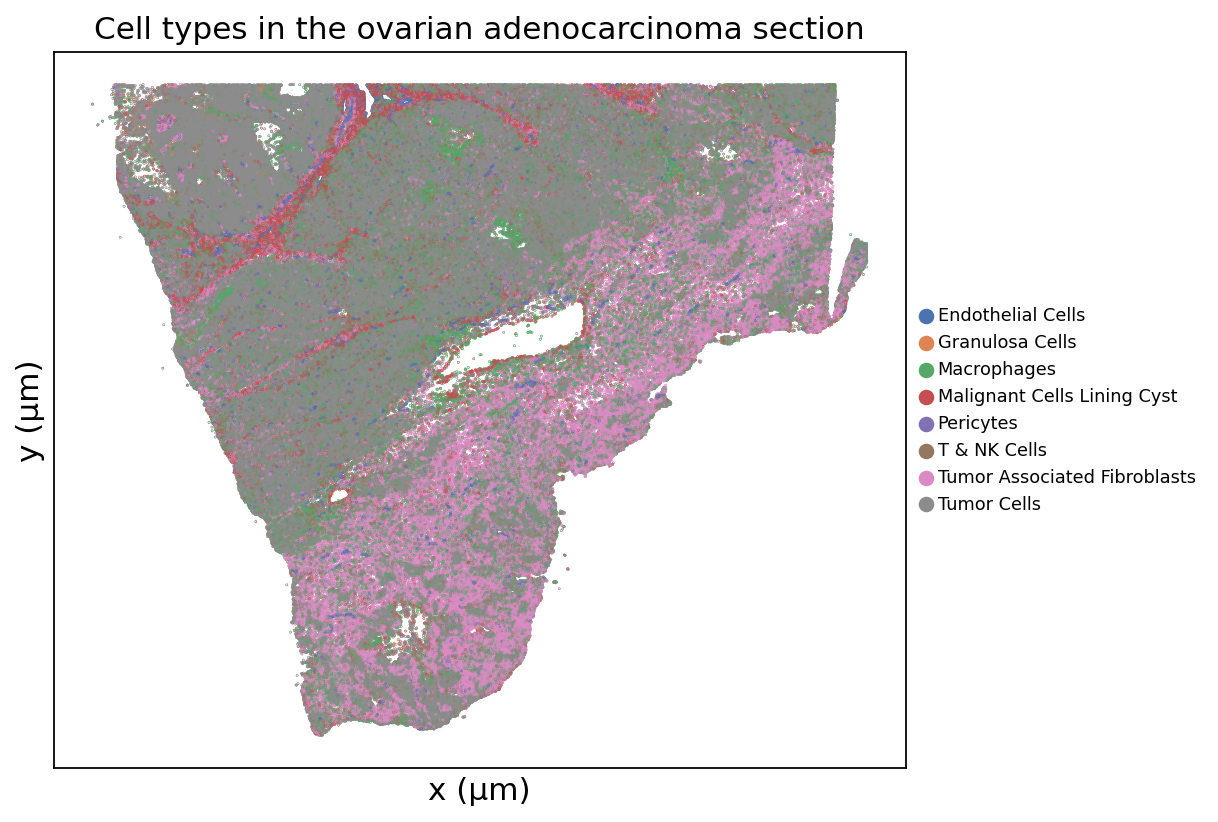

In [5]:
sq.pl.spatial_scatter(
    adata,
    shape=None,             
    color=CT_KEY,
    library_id='sample',
    img=False,
    size=0.12,                 # tune; the original s=0.12 is not directly equivalent
    figsize=(7.5, 8),
    title="Cell types in the ovarian adenocarcinoma section",
    legend_fontsize=8,
    legend_loc="right margin",
    frameon=True,
    axis_label=["x (µm)", "y (µm)"],
)

### Defining the neighborhood

Every method in this chapter requires a definition of spatial proximity, and this choice determines the spatial scale emphasized by the analysis.
We use two forms.
First, a binary contact graph based on Delaunay triangulation, pruned at about one cell diameter.
Second, a smooth Gaussian kernel for interactions that may act over a broader spatial range, which LIANA+ uses by default to weight cell pairs by distance.
The contact-graph cutoff sets a maximum edge length, whereas the Gaussian bandwidth controls how rapidly weights decrease with distance.

> Elsewhere, for example in MISTy {cite:p}`tanevski2022explainable`, you will encounter these two flavors as *juxtaview* and *paraview*.

We start with the contact graph.
To choose a reasonable distance cutoff, we first construct an unpruned Delaunay graph of the cell centroids and inspect the distribution of its edge lengths.
This gives us an empirical estimate of the spatial scale of direct cell–cell contacts in this tissue.

In [7]:
%%time
# Delaunay triangulation of the cell centroids, unpruned, to look at the edge lengths
sq.gr.spatial_neighbors_delaunay(adata, spatial_key=SPATIAL_KEY, key_added="contact")
edges = np.asarray(adata.obsp["contact_distances"].data)

# the distance to the single nearest neighbour is NOT the quantity that prunes edges
from sklearn.neighbors import NearestNeighbors

coords = np.asarray(adata.obsm[SPATIAL_KEY])
nn_dist = NearestNeighbors(n_neighbors=2).fit(coords).kneighbors(coords)[0][:, 1]

print(f"nearest-neighbour distance: median {np.median(nn_dist):6.1f} µm, 95th percentile {np.quantile(nn_dist, 0.95):6.1f} µm")
print(f"Delaunay edge length:       median {np.median(edges):6.1f} µm, 90th percentile {np.quantile(edges, 0.90):6.1f} µm")
print(f"mean degree of the unpruned graph: {np.asarray((adata.obsp['contact_connectivities'] > 0).sum(1)).mean():.2f}")

INFO     Creating graph using `None` transform and `1` libraries.                                                  
nearest-neighbour distance: median    8.2 µm, 95th percentile   12.3 µm
Delaunay edge length:       median   12.3 µm, 90th percentile   20.7 µm
mean degree of the unpruned graph: 6.00
CPU times: user 2.13 s, sys: 157 ms, total: 2.29 s
Wall time: 2.38 s


The median Delaunay edge length is 12.3 μm, and 90% of edges are shorter than 20.7 μm.
We therefore use 20 μm, approximately one cell diameter, as the cutoff for the contact graph.
Longer Delaunay edges are more likely to bridge gaps or tissue boundaries than to represent direct cell–cell contact.

For comparison, the median nearest-neighbor distance is only 8.2 μm.
This mainly reflects how tightly cells are packed.

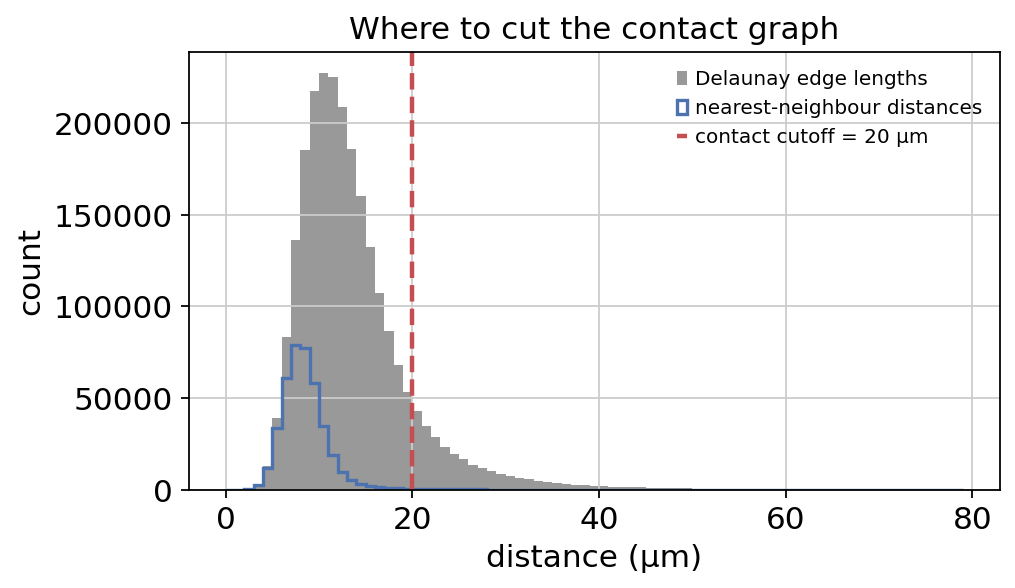

88.7% of Delaunay edges are shorter than 20 µm


In [8]:
CONTACT_CUTOFF = 20.0  # µm, one cell diameter

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.hist(edges, bins=np.arange(0, 80, 1), color="#999999", label="Delaunay edge lengths")
ax.hist(nn_dist, bins=np.arange(0, 80, 1), histtype="step", color="#4C72B0", lw=1.5, label="nearest-neighbour distances")
ax.axvline(CONTACT_CUTOFF, color="#C44E52", lw=2, ls="--", label=f"contact cutoff = {CONTACT_CUTOFF:.0f} µm")
ax.set_xlabel("distance (µm)")
ax.set_ylabel("count")
ax.set_title("Where to cut the contact graph")
ax.legend(frameon=False, fontsize=9)
plt.show()

print(f"{(edges <= CONTACT_CUTOFF).mean():.1%} of Delaunay edges are shorter than {CONTACT_CUTOFF:.0f} µm")

In [9]:
%%time
# the pruned contact graph: a Delaunay edge is kept only if it is shorter than the cutoff.
# NOTE: `radius` has to be a tuple (min, max) - a list is silently ignored.
sq.gr.spatial_neighbors_delaunay(
    adata, spatial_key=SPATIAL_KEY, radius=(0.0, CONTACT_CUTOFF), key_added="contact"
)
degree = np.asarray((adata.obsp["contact_connectivities"] > 0).sum(1)).ravel()
print(f"contact graph: mean degree {degree.mean():.2f}, {(degree == 0).sum():,} isolated cells")

INFO     Creating graph using `None` transform and `1` libraries.                                                  
contact graph: mean degree 5.32, 1,318 isolated cells
CPU times: user 1.5 s, sys: 113 ms, total: 1.61 s
Wall time: 1.65 s


For the distance-weighted neighborhood, we next choose the bandwidth of the Gaussian kernel.
`li.pp.query_bandwidth` shows how the average number of neighboring cells changes as the bandwidth increases.

In this tissue, a bandwidth of about 17 µm corresponds to roughly seven neighboring cells on average.
We opt for a bandwidth of **30 µm**, which should roughly correspond to local paracrine signaling.
This also keeps the two neighborhood definitions on a similar spatial scale while still allowing the Gaussian kernel to downweight more distant cells.

,bandwidth,neighbours
0,5.000000,0.0
1,6.153846,0.0
2,7.307692,0.0
3,8.461538,1.0
4,9.615385,1.0
5,10.769231,2.0
6,11.923077,3.0
7,13.076923,4.0
8,14.230769,4.0
9,15.384615,5.0


CPU times: user 15.9 s, sys: 103 ms, total: 16 s
Wall time: 16.4 s


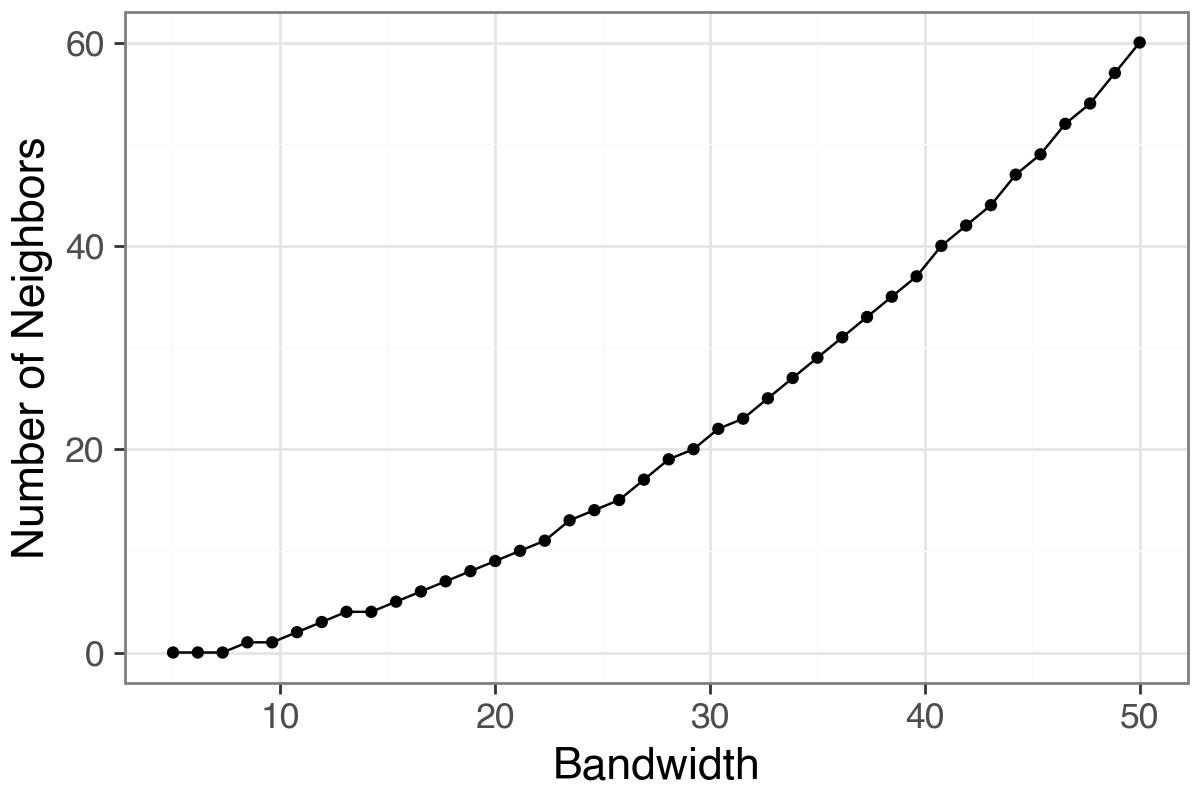

In [10]:
%%time
bw_plot, bw_df = li.pp.query_bandwidth(coordinates=coords, start=5, end=50, interval_n=40)
display(bw_df.head(10))
bw_plot

In [11]:
%%time
BANDWIDTH = 20.0  # µm

li.pp.spatial_neighbors(
    adata,
    bandwidth=BANDWIDTH,
    cutoff=0.1,
    kernel="gaussian",
    spatial_key=SPATIAL_KEY,
    set_diag=False,
    verbose=True,
)
print("kernel graph in adata.obsp['spatial_connectivities']:", adata.obsp["spatial_connectivities"].shape)
print(f"mean number of non-zero weights per cell: {adata.obsp['spatial_connectivities'].getnnz(axis=1).mean():.1f}")

kernel graph in adata.obsp['spatial_connectivities']: (400600, 400600)
mean number of non-zero weights per cell: 101.0
CPU times: user 9.81 s, sys: 463 ms, total: 10.3 s
Wall time: 10.5 s


`li.pl.connectivity` shows what that kernel looks like for a single cell: the chosen cell is the bright point and the color of every other cell is the weight with which it enters that cell's neighborhood.
Weights below `cutoff=0.1` are set to zero, which is what keeps the matrix sparse.

/var/folders/rx/lgxbr_g961l7_cjsb7lwcs480000gn/T/ipykernel_3001/3997700466.py:1: UserWarning: This function will be deprecated in the next version. Please use scanpy or squidpy for plotting spatial connectivities.


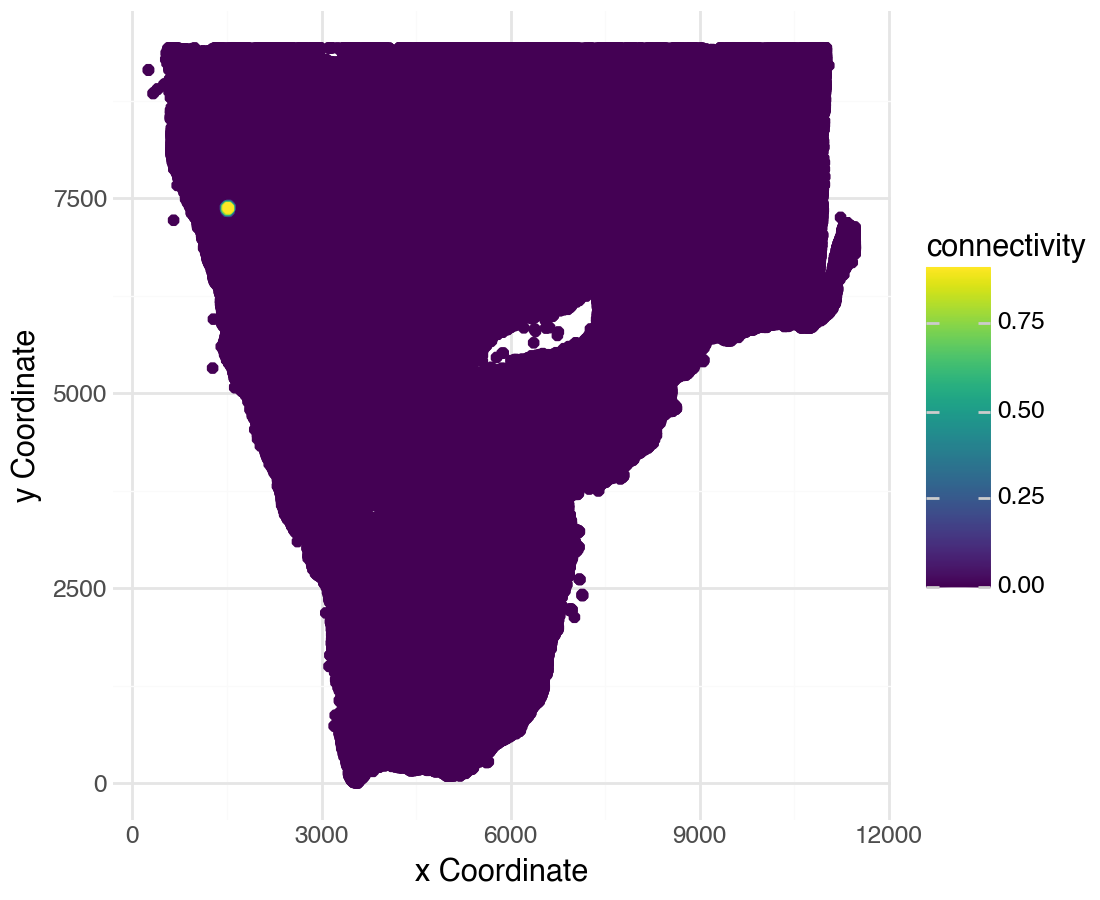

In [12]:
li.pl.connectivity(adata, idx=200_000, size=1.5, figure_size=(5.5, 4.5))

### Filtering to spatially variable genes

Because we are interested in communication patterns that differ across spatial regions of the tissue, we first restrict the analysis to genes that themselves show spatial structure (variance in space).
Genes that are expressed nearly uniformly across the section contribute little information about where communication may differ, while very sparsely detected genes can produce unstable spatial patterns.
Filtering these genes therefore focuses the analysis on spatially informative signals and reduces the multiple-testing burden.

We quantify spatial autocorrelation for each gene using Moran's I with `sq.gr.spatial_autocorr` on the kernel graph, and retain genes with a positive Moran's I and an FDR below 0.05.
We then restrict the ligand-receptor resource to pairs for which both genes pass this filter.

Uniformly expressed genes can also participate in cell–cell communication.
A spatially varying ligand could interact with a broadly expressed receptor, or vice versa.
Requiring both genes to pass the filter therefore reduces the search space, but may also exclude relevant interactions.

In [13]:
# cacluate morans'I, skip because takes long, precalculated in adata.uns

# %%time
# sq.gr.spatial_autocorr(
#     adata,
#     mode="moran",
#     genes=adata.var_names,          # by default squidpy would only test highly variable genes
#     connectivity_key="spatial_connectivities",
#     use_raw=False,
#     n_perms=None,                   # the normal approximation is enough for a filter
#     n_jobs=16,
#     show_progress_bar=False,
# )

In [14]:
moran = adata.uns["moranI"]
svg = moran.index[(moran["I"] > 0.01) & (moran["pval_norm_fdr_bh"] < 0.05)]

We plot the Moran's I score distribution sorted by gene rank with the spatially-variable gene cut-off and the top 5 svg genes. 

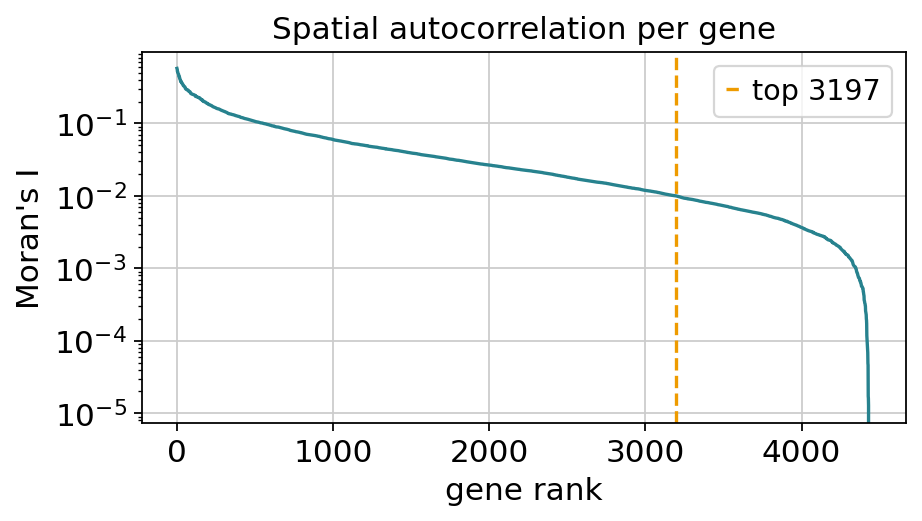


3,197 of 3,197 genes are spatially variable


,I,pval_norm,var_norm,pval_norm_fdr_bh
POSTN,0.575240,0.0,1.888382e-07,0.0
TNXB,0.562507,0.0,1.888382e-07,0.0
MMP11,0.555111,0.0,1.888382e-07,0.0
BCAM,0.522425,0.0,1.888382e-07,0.0
COL5A1,0.520887,0.0,1.888382e-07,0.0


In [15]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(np.arange(1, len(moran) + 1), moran["I"].values, color="#27828E")
ax.axvline(len(svg), color="#EE9B00", ls="--", label=f"top {len(svg)}")
ax.set(xlabel="gene rank", ylabel="Moran's I", yscale="log", title="Spatial autocorrelation per gene")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n{len(svg):,} of {adata.n_vars:,} genes are spatially variable")
display(moran.head())

In [16]:
adata = adata[:, [g for g in adata.var_names if g in set(svg)]].copy()
print("adata after the SVG filter:", adata.shape)

adata after the SVG filter: (400600, 3197)


In [17]:
resource = li.rs.select_resource("consensus")
genes = set(adata.var_names)
resource = resource[resource["ligand"].isin(genes) & resource["receptor"].isin(genes)].reset_index(drop=True)
print(f"consensus resource restricted to the panel and the SVG filter: {len(resource):,} ligand-receptor pairs")
display(resource.head())

## Part 1: Who is near whom, and at what distance?

### Neighborhood enrichment analysis

Neighborhood enrichment analysis (NEA) asks whether particular cell types tend to occur next to one another more or less often than expected by chance.
Starting from the contact graph, we count the number of edges connecting each pair of cell types.
We then repeatedly shuffle the cell-type labels while keeping the graph fixed to obtain a null distribution for these counts.

The observed number of contacts is compared with this null distribution and reported as a z-score.
Positive values indicate that two cell types are neighbors more often than expected, whereas negative values indicate that they are neighbors less often than expected.
Because the graph and the number of cells of each type are preserved during the permutations, the comparison accounts for the geometry of the tissue and differences in cell-type abundance.

NEA captures which cell types tend to occur near one another, but proximity alone does not imply communication.
The results also depend on the neighborhood definition, since changing the distance cutoff changes which cells are considered neighbors and therefore which cell-type pairs appear enriched or depleted.

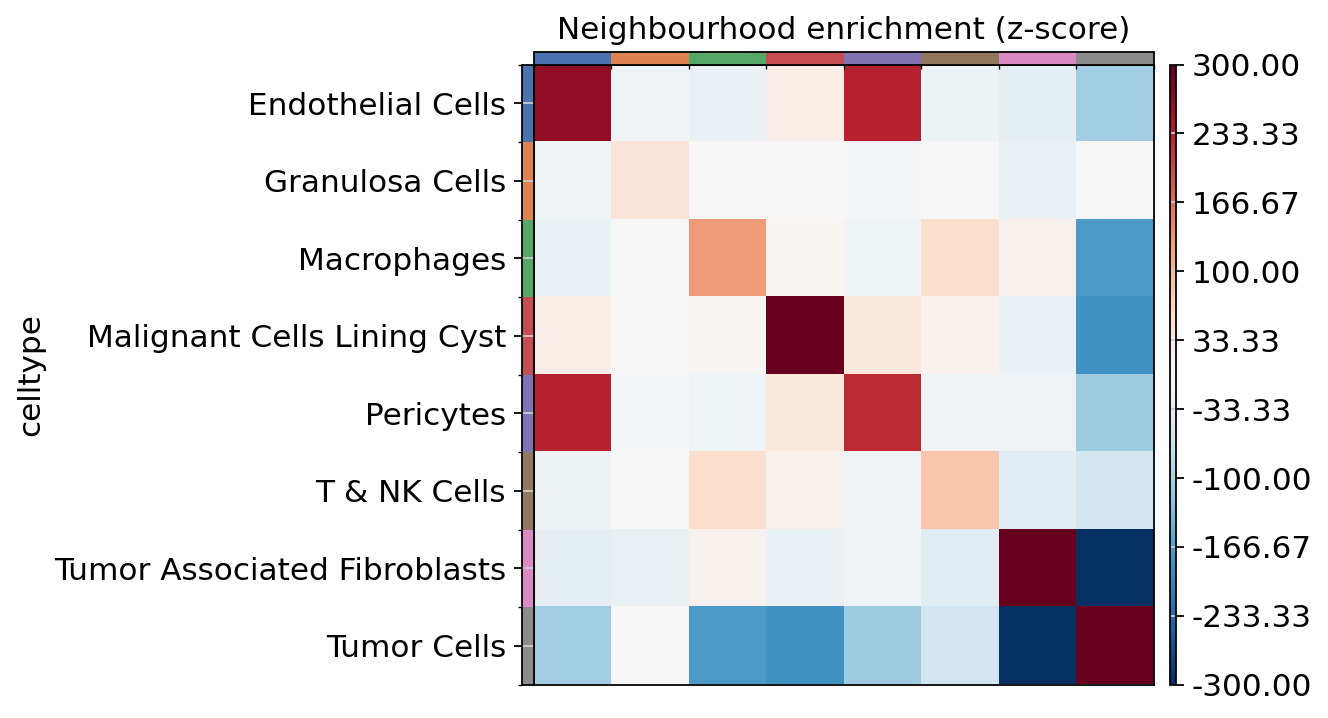

CPU times: user 14.8 s, sys: 50.3 ms, total: 14.9 s
Wall time: 15 s


In [24]:
%%time
sq.gr.nhood_enrichment(
    adata, cluster_key=CT_KEY, connectivity_key="contact", n_perms=1000, seed=0, show_progress_bar=False
)
CT_ORDER = np.unique(adata.obs[CT_KEY].values)
zscores = pd.DataFrame(
    adata.uns[f"{CT_KEY}_nhood_enrichment"]["zscore"], index=CT_ORDER, columns=CT_ORDER
)

fig, ax = plt.subplots(figsize=(6.2, 5.2))
sq.pl.nhood_enrichment(
    adata, cluster_key=CT_KEY, cmap="RdBu_r", vmin=-300, vmax=300, ax=ax, title="Neighbourhood enrichment (z-score)"
)
plt.show()

In [25]:
nea = (
    zscores.reset_index(names="source")
    .melt(id_vars="source", var_name="target", value_name="zscore")
)
print("most co-localised cell type pairs (heterotypic only):")
display(nea.query("source != target").sort_values("zscore", ascending=False).head(8).reset_index(drop=True))
print(f"\nrunning example, {EXAMPLE_SOURCE} <-> {EXAMPLE_TARGET}: z = {zscores.loc[EXAMPLE_SOURCE, EXAMPLE_TARGET]:.1f}")
print(f"for contrast,   {EXAMPLE_SOURCE} <-> Tumor Cells: z = {zscores.loc[EXAMPLE_SOURCE, 'Tumor Cells']:.1f}")

most co-localised cell type pairs (heterotypic only):


,source,target,zscore
0,Endothelial Cells,Pericytes,230.418104
1,Pericytes,Endothelial Cells,230.418104
2,Macrophages,T & NK Cells,49.040450
3,T & NK Cells,Macrophages,49.040450
4,Malignant Cells Lining Cyst,Pericytes,30.749900
5,Pericytes,Malignant Cells Lining Cyst,30.749900
6,Malignant Cells Lining Cyst,Endothelial Cells,20.013160
7,Endothelial Cells,Malignant Cells Lining Cyst,20.013160



running example, Tumor Associated Fibroblasts <-> Macrophages: z = 12.8
for contrast,   Tumor Associated Fibroblasts <-> Tumor Cells: z = -494.4


The diagonal is strongly positive for most cell types, indicating that cells of the same type tend to cluster together in space.
Among the heterotypic pairs, endothelial cells and pericytes show particularly strong enrichment, consistent with the close association of pericytes with blood vessels.
This provides a useful sanity check for the spatial annotation.

For our running example, tumor-associated fibroblasts and macrophages are also enriched as neighbors, whereas tumor-associated fibroblasts and tumor cells show strong depletion.
This suggests that fibroblasts and tumor cells occupy relatively distinct spatial compartments, with macrophages preferentially found in the fibroblast-rich regions.

The magnitude of these z-scores should be interpreted with some care.
A larger absolute z-score means that the observed number of contacts is further from what would be expected under the permutation null.
However, the z-score is not a direct measure of biological effect size: it also depends on factors such as the number of cells and how the neighborhood is defined.
In particular, larger cell numbers can lead to larger z-scores, even for comparable spatial preferences {cite:p}`schiller2026comparison`.

### The cross pair-correlation function

Neighborhood enrichment gives us a single summary of whether two cell types tend to occur next to each other, but it does not tell us at what spatial scale this association occurs.
The cross pair-correlation function, $g(r)$, addresses this by measuring how often cells of one type are found at a given distance $r$ from cells of another type.

For each distance, we count target cells within a thin ring around cells of the source type and compare this with the number expected from the overall target-cell density.
A value of $g(r) > 1$ indicates enrichment at that distance, whereas $g(r) < 1$ indicates depletion.

To compare many cell-type pairs, we summarize each curve by the mean $\log_2 g(r)$ up to a chosen maximum distance and record the distance at which $g(r)$ reaches its maximum.

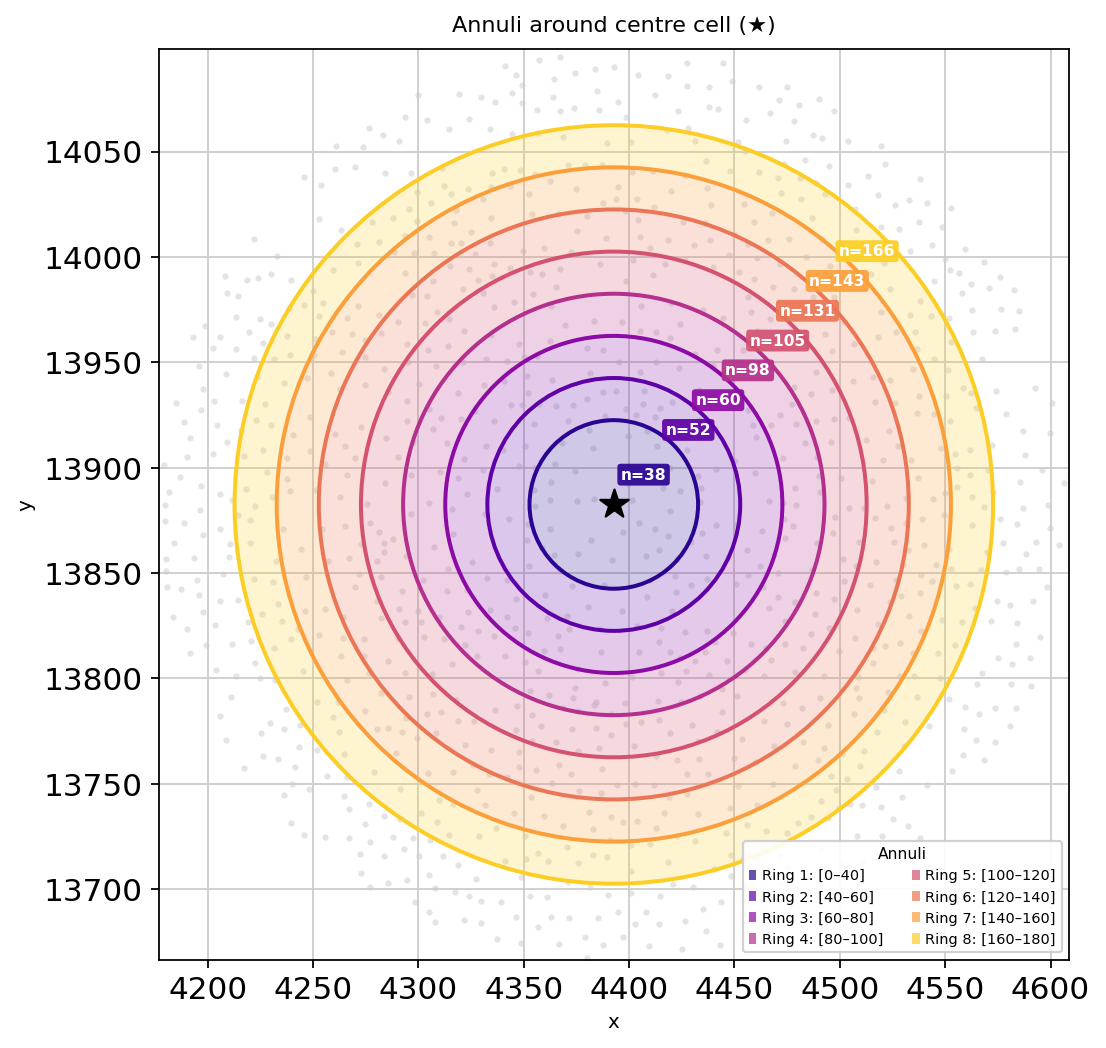

In [26]:
li.pl.annulus(
    adata, spatial_key=SPATIAL_KEY, radius_step=20, n_rings=8, seed=1337,
    figure_size=(7, 7), return_fig=False,
)

In [27]:
%%time
li.mt.cross_pcf(
    adata,
    groupby=CT_KEY,
    spatial_key=SPATIAL_KEY,
    max_radius=250,
    radius_step=20,
    min_cells=100,
    key_added="cross_pcf",
    verbose=True,
)
pcf = adata.uns["cross_pcf"]
print("g(r) per radius (the first annulus is extended, so the grid starts 0, 40, 60, ...):")
display(pcf.head())
print("radii:", sorted(pcf["radius"].unique()))

Using `.X`!
/Users/francescadrummer/anaconda3/envs/workshop_2025/lib/python3.12/site-packages/liana/_core/_pipe_utils/_pre.py:252: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
Computing cross-PCF over 8 retained cell types (28 pairs emitted).


g(r) per radius (the first annulus is extended, so the grid starts 0, 40, 60, ...):


,source,target,interaction,radius,g
0,Endothelial Cells,Granulosa Cells,Endothelial Cells^Granulosa Cells,0.0,0.267444
1,Endothelial Cells,Granulosa Cells,Endothelial Cells^Granulosa Cells,40.0,0.388438
2,Endothelial Cells,Granulosa Cells,Endothelial Cells^Granulosa Cells,60.0,0.385292
3,Endothelial Cells,Granulosa Cells,Endothelial Cells^Granulosa Cells,80.0,0.447517
4,Endothelial Cells,Granulosa Cells,Endothelial Cells^Granulosa Cells,100.0,0.450199


radii: [np.float64(0.0), np.float64(40.0), np.float64(60.0), np.float64(80.0), np.float64(100.0), np.float64(120.0), np.float64(140.0), np.float64(160.0), np.float64(180.0), np.float64(200.0), np.float64(220.0), np.float64(240.0), np.float64(260.0)]
CPU times: user 29.1 s, sys: 1min 15s, total: 1min 44s
Wall time: 10min 57s


In [28]:
auc = li.mt.get_lric_auc(adata, "cross_pcf", max_dist=50, min_bins=2)
print("summary of each curve: mean log2 g(r) up to 50 µm, and the radius at which g(r) peaks")
display(auc.sort_values("score", ascending=False).head(8).reset_index(drop=True))
display(auc.sort_values("score").head(4).reset_index(drop=True))

summary of each curve: mean log2 g(r) up to 50 µm, and the radius at which g(r) peaks


,source,target,interaction,score,peak_radius
0,Endothelial Cells,Pericytes,Endothelial Cells^Pericytes,2.110385,0.0
1,Malignant Cells Lining Cyst,Pericytes,Malignant Cells Lining Cyst^Pericytes,1.463117,40.0
2,Endothelial Cells,Malignant Cells Lining Cyst,Endothelial Cells^Malignant Cells Lining Cyst,1.020345,40.0
3,Macrophages,T & NK Cells,Macrophages^T & NK Cells,0.285744,0.0
4,Pericytes,Tumor Associated Fibroblasts,Pericytes^Tumor Associated Fibroblasts,0.146760,40.0
5,Malignant Cells Lining Cyst,T & NK Cells,Malignant Cells Lining Cyst^T & NK Cells,0.016894,0.0
6,Macrophages,Malignant Cells Lining Cyst,Macrophages^Malignant Cells Lining Cyst,0.010477,0.0
7,Granulosa Cells,Tumor Cells,Granulosa Cells^Tumor Cells,-0.016826,40.0


,source,target,interaction,score,peak_radius
0,Endothelial Cells,Granulosa Cells,Endothelial Cells^Granulosa Cells,-1.633469,0.0
1,Granulosa Cells,Pericytes,Granulosa Cells^Pericytes,-1.572890,40.0
2,Tumor Associated Fibroblasts,Tumor Cells,Tumor Associated Fibroblasts^Tumor Cells,-1.465074,0.0
3,Granulosa Cells,Tumor Associated Fibroblasts,Granulosa Cells^Tumor Associated Fibroblasts,-1.158110,0.0


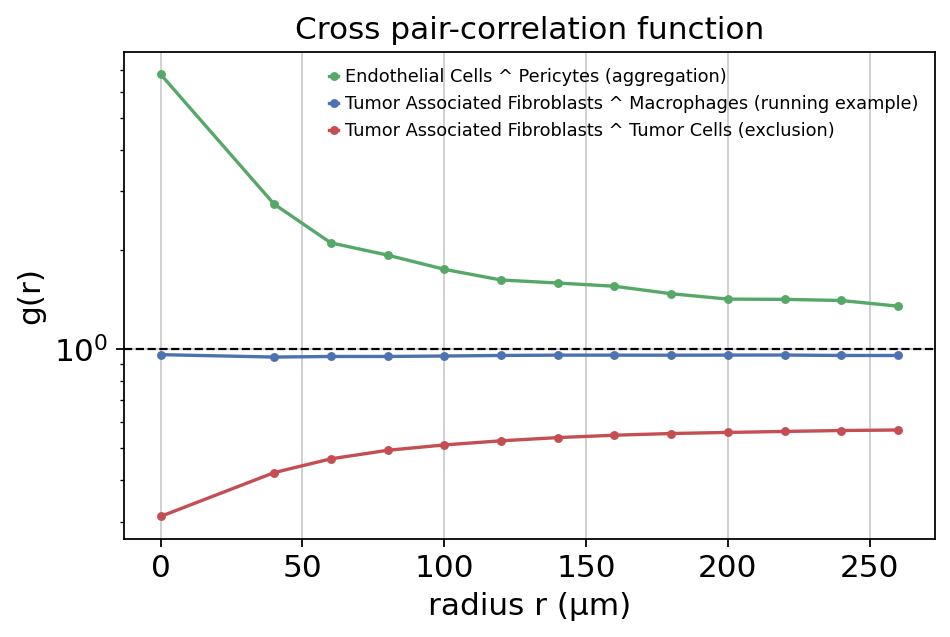

Tumor Associated Fibroblasts ^ Macrophages: g(r) ranges from 0.94 to 0.96 over 0-260 µm
Endothelial Cells ^ Pericytes: g(0-40 µm) = 6.79
Tumor Associated Fibroblasts ^ Tumor Cells: g(0-40 µm) = 0.31


In [29]:
def gcurve(a, b):
    """g(r) for one unordered cell type pair (cross_pcf stores each pair once)."""
    sel = pcf[((pcf["source"] == a) & (pcf["target"] == b)) | ((pcf["source"] == b) & (pcf["target"] == a))]
    return sel.sort_values("radius")

PAIRS = [
    ("Endothelial Cells", "Pericytes", "#55A868", "aggregation"),
    (EXAMPLE_SOURCE, EXAMPLE_TARGET, "#4C72B0", "running example"),
    (EXAMPLE_SOURCE, "Tumor Cells", "#C44E52", "exclusion"),
]
fig, ax = plt.subplots(figsize=(6.5, 4))
for a, b, colour, label in PAIRS:
    g = gcurve(a, b)
    ax.plot(g["radius"], g["g"], "-o", ms=3, color=colour, label=f"{a} ^ {b} ({label})")
ax.axhline(1, ls="--", c="k", lw=1)
ax.set_xlabel("radius r (µm)")
ax.set_ylabel("g(r)")
ax.set_yscale("log")
ax.set_title("Cross pair-correlation function")
ax.legend(frameon=False, fontsize=8)
plt.show()

g_run = gcurve(EXAMPLE_SOURCE, EXAMPLE_TARGET)
print(f"{EXAMPLE_SOURCE} ^ {EXAMPLE_TARGET}: g(r) ranges from {g_run['g'].min():.2f} to {g_run['g'].max():.2f} over 0-260 µm")
print(f"Endothelial Cells ^ Pericytes: g(0-40 µm) = {gcurve('Endothelial Cells', 'Pericytes')['g'].iloc[0]:.2f}")
print(f"{EXAMPLE_SOURCE} ^ Tumor Cells: g(0-40 µm) = {gcurve(EXAMPLE_SOURCE, 'Tumor Cells')['g'].iloc[0]:.2f}")

The three curves illustrate why it is useful to look beyond a single neighborhood-enrichment score.
Endothelial cells and pericytes show strong enrichment at short distances, with $g(r)$ around 7 in the first bin.
The enrichment decreases with distance but remains above 1 across the full range shown, consistent with a strong spatial association between the two cell types.
Tumor-associated fibroblasts and tumor cells show the opposite pattern: $g(r)$ is well below 1 at short distances and remains below 1 throughout the measured range, indicating spatial separation across multiple scales.

Our running example, tumor-associated fibroblasts and macrophages, is much less pronounced.
Here, $g(r)$ stays close to 1 across all distances, with only a slight depletion.
This may at first seem inconsistent with the positive neighborhood-enrichment z-score above, but the two statistics use different summaries and different null models.
NEA asks whether the number of edges between the two cell types in the 20 µm contact graph differs from what is expected after shuffling cell-type labels.
The cross pair-correlation function instead compares the local density of one cell type around the other with its overall density in the tissue.

Together, the results suggest that any short-range association between fibroblasts and macrophages is modest in magnitude and does not correspond to a pronounced spatial enrichment over the broader distance range examined here.

Note that `max_dist=50` refers to the radii included in the summary, not to a continuous interval from 0 to 50 µm.
With the radius grid used here, only the bins at 0 and 40 µm fall within this range.
The resulting score therefore summarizes $g(r)$ over these first two distance bins.
As with the neighborhood-enrichment analysis, comparisons should always be interpreted with the chosen spatial scale in mind.

### From cell types to a ligand-receptor pair

So far, we have only asked where different cell types are located relative to one another.
LRIC (`li.mt.lric`) extends this idea to individual ligand-receptor pairs by incorporating their expression levels.
For a given sender-receiver pair, contributions at distance $r$ are weighted by ligand expression in the sender and receptor expression in the receiver.

To separate spatial expression patterns from differences in overall expression between cell types, LRIC constructs a null by permuting the expression values within each cell type.
This allows us to ask whether a ligand-receptor pair is spatially enriched beyond what we would already expect from the locations of the two cell types.

Here, we run LRIC only for our running example.
Applying it to every combination of sender-receiver cell types and ligand-receptor pairs is considerably more computationally expensive.

In [30]:
%%time
lric_resource = resource.query("ligand == @EXAMPLE_LIGAND and receptor == @EXAMPLE_RECEPTOR")
li.mt.lric(
    adata,
    resource=lric_resource,
    groupby=CT_KEY,
    spatial_key=SPATIAL_KEY,
    cell_types=[EXAMPLE_SOURCE, EXAMPLE_TARGET],
    max_radius=250,
    radius_step=20,
    expr_prop=0.1,
    use_raw=False,
    key_added="lric_ct",
    verbose=True,
)
display(li.mt.get_lric_auc(adata, "lric_ct", max_dist=50, min_bins=2))
display(adata.uns["lric_ct"].query("source == @EXAMPLE_SOURCE").head())

`min_cells=None`: dropping cell types with <= 1.0% of 400600 cells (min_cells=4007).
Using `.X`!


Using provided `resource`.


/Users/francescadrummer/anaconda3/envs/workshop_2025/lib/python3.12/site-packages/liana/_core/_pipe_utils/_pre.py:252: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Users/francescadrummer/anaconda3/envs/workshop_2025/lib/python3.12/site-packages/liana/method/sp/_LRIC.py:890: UserWarning: The following cell identities were excluded: Granulosa Cells
Running LRIC (conditional within-type null) over 7 retained cell types (2 directed pairs emitted).
LRIC: 100%|██████████| 2/2 [00:00<00:00,  3.02it/s]


,source,target,ligand_complex,receptor_complex,interaction,score,peak_radius
0,Macrophages,Tumor Associated Fibroblasts,THBS1,LRP1,THBS1^LRP1,0.417796,0.0
1,Tumor Associated Fibroblasts,Macrophages,THBS1,LRP1,THBS1^LRP1,0.079690,0.0


,source,target,ligand_complex,receptor_complex,interaction,radius,g,g_expr,g_pcf
13,Tumor Associated Fibroblasts,Macrophages,THBS1,LRP1,THBS1^LRP1,0.0,1.068788,1.113069,0.960217
14,Tumor Associated Fibroblasts,Macrophages,THBS1,LRP1,THBS1^LRP1,40.0,1.044928,1.106612,0.944258
15,Tumor Associated Fibroblasts,Macrophages,THBS1,LRP1,THBS1^LRP1,60.0,1.042252,1.099495,0.947937
16,Tumor Associated Fibroblasts,Macrophages,THBS1,LRP1,THBS1^LRP1,80.0,1.038385,1.095239,0.948090
17,Tumor Associated Fibroblasts,Macrophages,THBS1,LRP1,THBS1^LRP1,100.0,1.040710,1.094130,0.951176


CPU times: user 30.7 s, sys: 1min 20s, total: 1min 51s
Wall time: 12min 31s


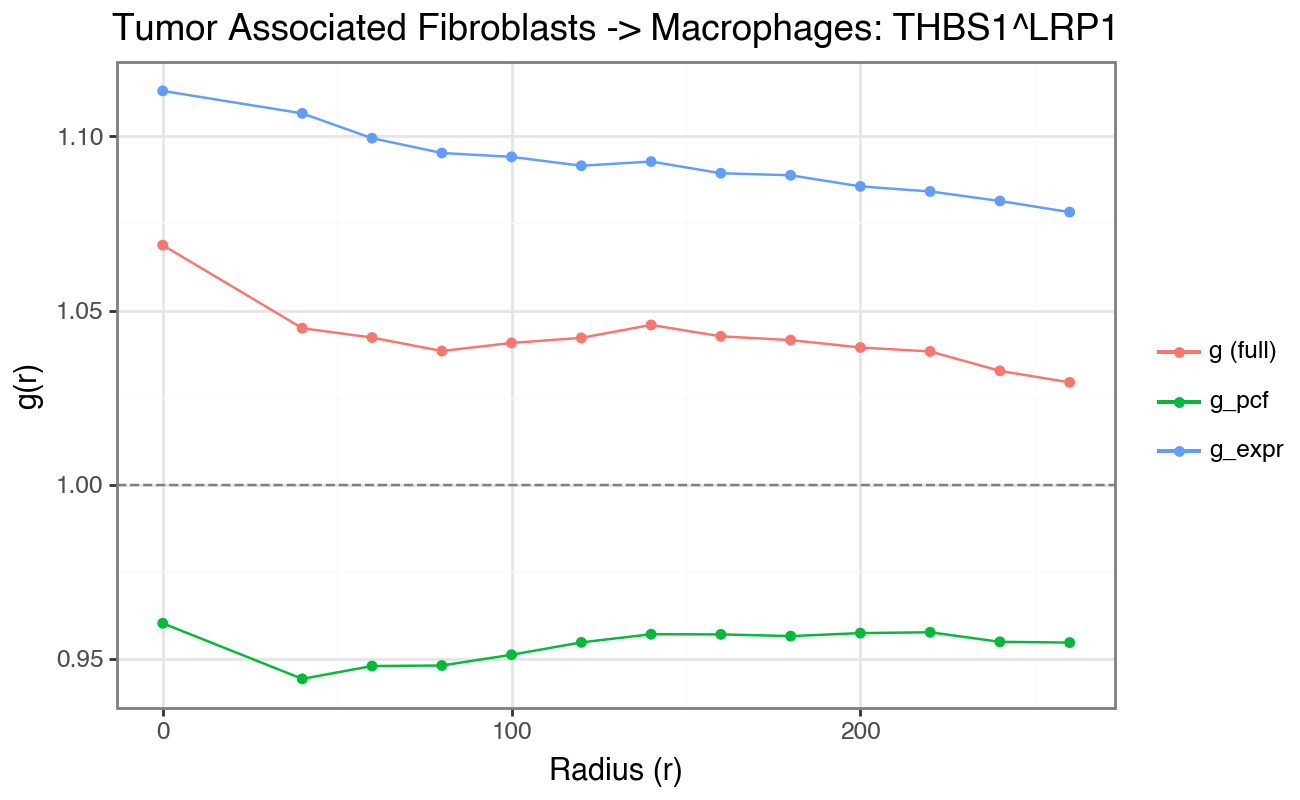

In [31]:
li.pl.lric_lineplot(
    adata,
    "lric_ct",
    source=EXAMPLE_SOURCE,
    target=EXAMPLE_TARGET,
    interaction=f"{EXAMPLE_LIGAND}^{EXAMPLE_RECEPTOR}",
    figure_size=(6.5, 4),
)

The decomposition shows that the spatial signal for *THBS1*–*LRP1* comes mainly from expression rather than from the arrangement of the two cell types.
The cell-type component, $g_{\mathrm{pcf}}(r)$, stays slightly below 1 across all distances, consistent with the weak depletion between tumor-associated fibroblasts and macrophages seen above.
In contrast, $g_{\mathrm{expr}}(r)$ is above 1 throughout the measured range and is strongest at short distances.
As a result, the full expression-weighted $g(r)$ is also above 1, despite the slight spatial separation of the two cell types.

For this ligand-receptor pair, expression therefore shows additional spatial co-enrichment beyond what we would expect from the locations of fibroblasts and macrophages alone.
The effect is strongest at short range and gradually weakens with distance.
This motivates including relatively short spatial scales in the bandwidth analysis in Part 2 (in particular the 30 µm end of the bandwidth sweep), while larger bandwidths provide a more permissive view of interactions extending across broader regions.
<!-- TODO (Francesca): verify -->

## Part 2: Which ligand-receptor pairs, given proximity?

### Spatial constraints on ligand-receptor analysis

As discussed in the Background section, ligand-receptor methods developed for dissociated data infer potential communication from gene expression without leveraging spatial information.
A ligand expressed in one cell type and its receptor in another can therefore score highly even if the two cell types occupy completely different regions of the tissue.

To illustrate this class of methods, we use CellPhoneDB {cite:p}`efremova2020cellphonedb`.
CellPhoneDB asks whether a ligand-receptor pair is expressed more specifically in a particular sender-receiver combination than expected after permuting the cell-type labels.
Its statistical score therefore reflects cell-type specificity rather than the magnitude of an interaction.

With spatial data, we can constrain this search using information about which cell types are actually close enough to interact.
We consider two approaches: a **hard constraint**, where implausible sender-receiver pairs are excluded altogether, and a **soft constraint**, where interactions are down-weighted according to spatial proximity.
A related strategy for spatially constraining CellPhoneDB was proposed by {cite:t}`garciaalonso2021mapping`.

In [ ]:
%%time
cellphonedb(
    adata,
    groupby=CT_KEY,
    resource_name="consensus",
    expr_prop=0.05,
    use_raw=False,
    n_perms=1000,
    seed=1337,
    n_jobs=1,
    verbose=False,   # the 1,000-permutation progress bar would fill the output
    key_added="cpdb_plain",
)
plain = adata.uns["cpdb_plain"]
print(f"\n{len(plain):,} rows: every sender x receiver x ligand-receptor combination that passed the expression filter")
display(plain.sort_values(["lr_means", "cellphone_pvals"], ascending=[False, True]).head(8).reset_index(drop=True))

/Users/francescadrummer/anaconda3/envs/workshop_2025/lib/python3.12/site-packages/liana/_core/_pipe_utils/_pre.py:252: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [ ]:
KEYS = ["source", "target", "ligand_complex", "receptor_complex"]


def ranked(df, name):
    """Rank every row of a CellPhoneDB result by score, then p-value."""
    out = df.sort_values(["lr_means", "cellphone_pvals"], ascending=[False, True]).reset_index(drop=True)
    out[name] = np.arange(1, len(out) + 1)
    return out[KEYS + [name, "lr_means", "cellphone_pvals"]].rename(
        columns={"lr_means": f"lr_means_{name}", "cellphone_pvals": f"pval_{name}"}
    )


def running(df, name):
    """The running example's row in a ranked table."""
    sel = df.query("source == @EXAMPLE_SOURCE and target == @EXAMPLE_TARGET and ligand_complex == @EXAMPLE_LIGAND and receptor_complex == @EXAMPLE_RECEPTOR")
    return sel.iloc[0] if len(sel) else None


plain_r = ranked(plain, "plain")
row = running(plain_r, "plain")
print(f"running example {EXAMPLE_SOURCE} -> {EXAMPLE_TARGET}, {EXAMPLE_LIGAND}^{EXAMPLE_RECEPTOR}")
print(f"  unconstrained: rank {int(row['plain']):,} of {len(plain_r):,}, score {row['lr_means_plain']:.2f}, p = {row['pval_plain']:.3f}")

### Hard constraint: restricting cell-type pairs

One way to incorporate spatial information is to exclude sender-receiver pairs that are not co-localized.
This follows the *microenvironments* approach introduced for CellPhoneDB by {cite:t}`garciaalonso2021mapping`: cell types are grouped according to which ones share a spatial environment, and CellPhoneDB only tests interactions between cell types that occur within the same environment.

Here, we derive this constraint directly from the neighborhood enrichment analysis in Part 1.
We retain cell-type pairs with an NEA z-score greater than 2, indicating that they occur next to each other more often than expected under the permutation null.
We also retain homotypic sender-receiver pairs.

In [ ]:
%%time
groupby_pairs = nea.query("zscore > 2")[["source", "target"]].reset_index(drop=True)
print(f"the mask keeps {len(groupby_pairs)} of {len(nea)} cell type pairs")
display(groupby_pairs.head(10))

cellphonedb(
    adata,
    groupby=CT_KEY,
    groupby_pairs=groupby_pairs,
    resource_name="consensus",
    expr_prop=0.05,
    use_raw=False,
    n_perms=1000,
    seed=1337,
    n_jobs=1,
    verbose=False,
    key_added="cpdb_hard",
)
hard = adata.uns["cpdb_hard"]
hard_r = ranked(hard, "hard")
row = running(hard_r, "hard")
print(f"\nhard-masked result: {len(hard):,} rows ({len(hard) / len(plain):.0%} of the unconstrained table)")
print(f"running example: rank {int(row['hard']):,} of {len(hard_r):,}")

In [ ]:
# what the mask costs: an interaction between two cell types that avoid each other disappears
masked_out = {tuple(x) for x in groupby_pairs.to_numpy()}
print(f"('Tumor Cells', 'Macrophages') in the mask: {('Tumor Cells', 'Macrophages') in masked_out}"
      f"  (NEA z = {zscores.loc['Tumor Cells', 'Macrophages']:.1f})")
q = "source == 'Tumor Cells' and target == 'Macrophages' and ligand_complex == 'MFGE8' and receptor_complex == 'ITGB3'"
print("rows for Tumor Cells -> Macrophages MFGE8^ITGB3:  unconstrained", len(plain.query(q)), " hard-masked", len(hard.query(q)))

### Soft constraint: weighting by spatial proximity

Rather than excluding cell-type pairs altogether, we can use spatial proximity as a continuous weight.
Cell-type pairs that tend to occur close together retain more of their ligand-receptor score, whereas spatially separated pairs are down-weighted.
This preserves all candidate interactions while prioritizing those that are more plausible given the tissue architecture.

CellChat v2 {cite:p}`jin2025cellchat` uses a related approach by incorporating a distance-dependent factor into its communication probabilities.
In LIANA+, `li.pp.spatial_pair_proximity` computes a representative distance between each pair of cell types and converts it into a proximity weight using a Gaussian kernel.
These weights can then be combined with the ligand-receptor scores.

The bandwidth controls the spatial scale over which proximity matters.
A small bandwidth, such as **30 µm**, strongly favors interactions between nearby cell types, whereas a larger bandwidth, such as **300 µm**, allows associations across broader tissue regions to retain substantial weight.
Below, we sweep across these spatial scales to examine how sensitive the inferred interaction ranking is to this choice.

In [ ]:
%%time
BANDWIDTHS = [30, 100, 300]
proximity = {}
for bw in BANDWIDTHS:
    proximity[bw] = li.pp.spatial_pair_proximity(
        adata, groupby=CT_KEY, spatial_key=SPATIAL_KEY, kernel="gaussian", bandwidth=bw, verbose=False
    )
display(proximity[30].head())

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
for ax, bw in zip(axes, [30, 300]):
    mat = proximity[bw].pivot(index="source", columns="target", values="proximity").loc[CT_ORDER, CT_ORDER]
    im = ax.imshow(mat.to_numpy(), cmap="magma", vmin=0, vmax=1)
    ax.set_xticks(range(len(CT_ORDER)), CT_ORDER, rotation=90, fontsize=7)
    ax.set_yticks(range(len(CT_ORDER)), CT_ORDER, fontsize=7)
    ax.set_title(f"proximity weight, bandwidth = {bw} µm")
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

At a bandwidth of **30 µm**, spatial proximity has a strong influence on the weights: cell-type pairs that tend to lie close together retain relatively high weights, whereas more distant pairs are strongly down-weighted.
At **300 µm**, most weights are close to 1, so spatial proximity has much less influence on the ranking.

The bandwidth therefore controls how strongly spatial distance constrains the analysis.
Smaller values emphasize local interactions, while larger values progressively approach the unconstrained ligand-receptor ranking.

In [ ]:
%%time
softs = {}
for bw in BANDWIDTHS:
    cellphonedb(
        adata,
        groupby=CT_KEY,
        resource_name="consensus",
        expr_prop=0.05,
        use_raw=False,
        n_perms=1000,
        seed=1337,
        n_jobs=1,
        verbose=False,
        key_added=f"cpdb_soft_bw{bw}",
        spatial_key=SPATIAL_KEY,
        spatial_kwargs={"kernel": "gaussian", "bandwidth": bw},
    )
    softs[bw] = adata.uns[f"cpdb_soft_bw{bw}"]
    print(f"bandwidth {bw:>3} µm: {len(softs[bw]):,} rows")

Check the top interactions

In [ ]:
def top_global(df, n=10):
    sel = df.sort_values(["lr_means", "cellphone_pvals"], ascending=[False, True]).head(n)
    return (sel["source"] + " -> " + sel["target"] + ": " + sel["ligand_complex"] + "^" + sel["receptor_complex"]).tolist()

display(
    pd.DataFrame(
        {"unconstrained": top_global(plain), **{f"soft {bw} µm": top_global(softs[bw]) for bw in BANDWIDTHS}},
        index=pd.RangeIndex(1, 11, name="rank"),
    )
)

In [ ]:
comparison = plain_r.merge(hard_r, on=KEYS, how="left")
for bw in BANDWIDTHS:
    comparison = comparison.merge(ranked(softs[bw], f"soft{bw}"), on=KEYS, how="left")

rank_cols = ["plain", "hard"] + [f"soft{bw}" for bw in BANDWIDTHS]
summary = pd.DataFrame(
    {
        "rows in the table": [len(plain_r), len(hard_r)] + [len(softs[bw]) for bw in BANDWIDTHS],
        "cell type pairs kept": [df.groupby(["source", "target"], observed=True).ngroups for df in [plain, hard] + [softs[bw] for bw in BANDWIDTHS]],
        f"rank of {EXAMPLE_LIGAND}^{EXAMPLE_RECEPTOR} ({EXAMPLE_SOURCE} -> {EXAMPLE_TARGET})": [running(comparison, c)[c] for c in rank_cols],
    },
    index=["unconstrained", "hard mask (NEA z > 2)"] + [f"soft, bandwidth {bw} µm" for bw in BANDWIDTHS],
)
display(summary)

In [ ]:
li.pl.dotplot(
    adata=adata,
    uns_key="cpdb_soft_bw100",
    colour="lr_means",
    size="cellphone_pvals",
    inverse_size=True,
    source_labels=[EXAMPLE_SOURCE, "Macrophages", "Tumor Cells"],
    target_labels=[EXAMPLE_TARGET, "Tumor Cells", "T & NK Cells"],
    top_n=15,
    orderby="lr_means",
    orderby_ascending=False,
    figure_size=(13, 9),
) + p9.theme(plot_margin=0.02)

The hard and soft constraints change the results in different ways.
The hard mask removes entire sender-receiver combinations: here, the number of tested cell-type pairs drops from 64 to 22, reducing the table from 24,155 to 8,841 interactions.
Because the mask acts at the cell-type level, an interaction is removed regardless of how strongly its ligand and receptor are expressed.
For example, the tumor-to-macrophage interaction *MFGE8*–*ITGB3* is excluded, even though we will see in Part 3 that it forms a clear local hotspot.

The soft constraint keeps all interactions but changes their ranking according to spatial proximity.
The effect is strongest at small bandwidths and weakens as the bandwidth increases.
For our running example, *THBS1*–*LRP1* from tumor-associated fibroblasts to macrophages moves from rank 124 without spatial information to rank 60 at 30 µm, then gradually back towards the unconstrained ranking at 100 and 300 µm.
This illustrates the trade-off between the two approaches: a hard constraint is more selective, whereas a soft constraint preserves more candidates and lets spatial proximity influence their priority.

### Global bivariate Moran's I

So far, we have described spatial relationships in terms of cell types.
Bivariate spatial statistics instead work directly at the gene level and do not require a cell-type annotation.
SpatialDM {cite:p}`li2023spatialdm` uses a bivariate extension of Moran's I to ask whether high expression of a ligand at one location tends to occur near high expression of its receptor at neighboring locations.
The neighborhood is defined by the same distance-weighted spatial graph introduced above (*paraview*).

A high global score indicates spatial co-expression of the ligand-receptor pair across the tissue.
Because the statistic is computed directly from gene expression and spatial proximity, it provides a complementary view to the cell-type-based analyses above.
Importantly, it measures spatial association rather than communication itself: a high score tells us that ligand and receptor expression are spatially aligned, not that signaling necessarily occurs between them.

In [ ]:
%%time
biv = li.mt.bivariate(
    adata,
    local_name=None,
    global_name="morans",
    resource_name="consensus",
    connectivity_key="spatial_connectivities",
    n_perms=None,          # permutation p-values would dominate the runtime of this chapter
    nz_prop=0.01,
    use_raw=False,
    verbose=True,
)
bivar = biv if isinstance(biv, pd.DataFrame) else biv.var.copy()
top_biv = bivar.sort_values("morans", ascending=False).head(10)
# n_perms=None means no permutation p-values are computed, so we do not show that column
display(top_biv[["ligand", "receptor", "ligand_props", "receptor_props", "morans"]].reset_index(drop=True))
print(f"\nrank of {EXAMPLE_LIGAND}^{EXAMPLE_RECEPTOR}: {int((bivar['morans'] > bivar.query('ligand == @EXAMPLE_LIGAND and receptor == @EXAMPLE_RECEPTOR')['morans'].iloc[0]).sum()) + 1} of {len(bivar):,}")

*THBS1*–*LRP1* ranks first among the 813 ligand-receptor pairs by global bivariate Moran's I. Their expression patterns overlap across broad regions of the tissue, producing a strong positive spatial association.
Because no cell-type labels enter this calculation, this provides complementary evidence to the fibroblast-to-macrophage interaction identified in Part 2.
The global score, however, does not tell us where within the tissue the association is strongest or which cell types contribute to it.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, gene in zip(axes, [EXAMPLE_LIGAND, EXAMPLE_RECEPTOR]):
    v = np.asarray(adata[:, gene].X.todense()).ravel()
    o = np.argsort(v)
    s = ax.scatter(coords[o, 0], coords[o, 1], c=v[o], s=0.15, cmap="magma", linewidths=0, rasterized=True)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{gene} (log-normalised)")
    fig.colorbar(s, ax=ax, shrink=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# a contrast: the same ligand with a different receptor, one that is expressed almost everywhere
CONTRAST_RECEPTOR = "CD47"
rows = []
for name, df in [("plain", plain), ("hard", hard)] + [(f"soft{bw}", softs[bw]) for bw in BANDWIDTHS]:
    r = ranked(df, name)
    for rec in (EXAMPLE_RECEPTOR, CONTRAST_RECEPTOR):
        sel = r.query("source == @EXAMPLE_SOURCE and target == @EXAMPLE_TARGET and ligand_complex == @EXAMPLE_LIGAND and receptor_complex == @rec")
        rows.append({"table": name, "receptor": rec, "rank": int(sel[name].iloc[0]) if len(sel) else np.nan})
contrast = pd.DataFrame(rows).pivot(index="receptor", columns="table", values="rank")
biv_small = bivar.query("ligand == @EXAMPLE_LIGAND and receptor in [@EXAMPLE_RECEPTOR, @CONTRAST_RECEPTOR]").set_index("receptor")
contrast["global Moran's I"] = biv_small["morans"].round(3)
contrast["receptor detected in"] = biv_small["receptor_props"].map("{:.0%}".format)
display(contrast)

The comparison with *THBS1*–*CD47* provides a useful contrast.
For the same tumor-associated fibroblast-to-macrophage pair, *THBS1*–*CD47* ranks above *THBS1*–*LRP1* in every CellPhoneDB-based analysis.
Yet its global bivariate Moran's I is negative ($-0.248$), whereas *THBS1*–*LRP1* shows a positive spatial association ($0.266$).

*CD47* is also detected much more broadly across the tissue than *LRP1* (77% versus 38% of cells), but broad expression alone does not imply spatial co-expression with *THBS1*.
Here, the two genes are not positively aligned across space.
This illustrates the distinction between the two approaches: a ligand-receptor pair can be specific to a particular sender-receiver combination without showing the same spatial association at the gene level.

## Part 3: Where does it happen locally?

### Inflow: local interaction scores by sender cell type

The bivariate scores tell us where ligand and receptor expression are spatially associated, but they do not identify which cell type contributes the ligand.
Inflow adds this information: For each receiver cell, it scores combinations of sender cell type, ligand and receptor by combining receptor expression in the receiver with the kernel-weighted ligand expression of neighboring cells from the specified sender type.

The result is a new object with the original cells as observations and features named `sender^ligand^receptor`.
Each feature can be mapped back onto the tissue to show where a particular sender–ligand–receptor combination is active.
`li.mt.compute_global_specificity` then aggregates these local scores by receiver cell type, providing a direct link back to the cell-type-level analyses in Part 2.

Inflow is part of an ongoing extension of LIANA+ (Alsayah et al., in preparation); for now, cite LIANA+ {cite:p}`dimitrov2024liana`.

In [ ]:
%%time
lrdata = li.mt.inflow(
    adata,
    groupby=CT_KEY,
    resource=resource,
    connectivity_key="spatial_connectivities",
    nz_prop=0.01,
    complex_sep=None,
    use_raw=False,
    verbose=True,
)
print("\ninflow returns a single AnnData: cells x sender^ligand^receptor")
print(lrdata)

In [ ]:
FEATURE = EXAMPLE_INTERACTION
scores = np.asarray(lrdata[:, FEATURE].X.todense()).ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
o = np.argsort(scores)
s = axes[0].scatter(coords[o, 0], coords[o, 1], c=scores[o], s=0.15, cmap="magma", linewidths=0, rasterized=True)
axes[0].set_title(f"inflow: {FEATURE}")
fig.colorbar(s, ax=axes[0], shrink=0.6)

aside = "Tumor Cells^MFGE8^ITGB3"
scores2 = np.asarray(lrdata[:, aside].X.todense()).ravel()
o2 = np.argsort(scores2)
s2 = axes[1].scatter(coords[o2, 0], coords[o2, 1], c=scores2[o2], s=0.15, cmap="magma", linewidths=0, rasterized=True)
axes[1].set_title(f"inflow: {aside} (removed by the hard mask)")
fig.colorbar(s2, ax=axes[1], shrink=0.6)

for ax in axes:
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

print(f"{FEATURE}: score > 0 in {(scores > 0).mean():.1%} of cells, mean {scores.mean():.3f}")
print(f"{aside}: score > 0 in {(scores2 > 0).mean():.1%} of cells, mean {scores2.mean():.3f}")

In [ ]:
# which cell types actually receive the signal?
receivers = (
    pd.DataFrame({CT_KEY: adata.obs[CT_KEY].to_numpy(), "inflow": scores})
    .groupby(CT_KEY, observed=True)["inflow"]
    .agg(mean_score="mean", prop_nonzero=lambda s: (s > 0).mean())
    .sort_values("mean_score", ascending=False)
)
display(receivers)

In [ ]:
fig, ax = li.pl.feature_by_group(
    lrdata,
    groupby=CT_KEY,
    feature=FEATURE,
    labels=["Tumor Cells", EXAMPLE_SOURCE, EXAMPLE_TARGET],
    figure_size=(12, 4.2),
)
plt.show()

In [ ]:
%%time
li.mt.compute_global_specificity(lrdata, groupby=CT_KEY, n_perms=100, seed=1337, verbose=False, use_raw=False)
gi = lrdata.uns["global_interactions"]
display(
    gi.query("source == @EXAMPLE_SOURCE and target == @EXAMPLE_TARGET")
    .sort_values("lr_mean", ascending=False)
    .head(8)
    .reset_index(drop=True)
)
li.pl.dotplot(
    liana_res=gi,
    colour="lr_mean",
    size="pval",
    inverse_size=True,
    source_labels=[EXAMPLE_SOURCE, "Tumor Cells", "Macrophages"],
    target_labels=[EXAMPLE_TARGET, "Tumor Cells", "T & NK Cells"],
    top_n=15,
    orderby="lr_mean",
    orderby_ascending=False,
    figure_size=(13, 9),
) + p9.theme(plot_margin=0.02)

The local inflow scores show where the signal is concentrated in the tissue.
For `Tumor Associated Fibroblasts^THBS1^LRP1`, the highest scores occur in the fibroblast-rich stromal bands.
When we group the scores by receiver cell type, macrophages have the strongest signal, consistent with the fibroblast-to-macrophage interaction identified in Part 2.
`li.mt.compute_global_specificity` performs this aggregation across all sender–ligand–receptor combinations.

There is limited direct evidence for *THBS1*–*LRP1* signaling from fibroblasts to macrophages in ovarian cancer.
*LRP1* can bind thrombospondin-1 (*THBS1*) directly, but this interaction can also mediate uptake and clearance of extracellular *THBS1* rather than signaling (endocytic clearance).
As such, whether this reflects actual signaling would need to be tested with additional evidence, ideally at the protein level or through perturbation experiments.

## Part 4: Multi-scale models
So far, we have analyzed one spatial scale at a time.
Multi-view and multi-scale methods such as MISTy {cite:p}`tanevski2022explainable`, Kasumi {cite:p}`tanevski2025learning`, SpatialDiva, SVCA {cite:p}`arnol2019modeling`, Steamboat {cite:p}`liang2025steamboat`, AMICI {cite:p}`hong2025amici` and InterScale {cite:p}`drummer2026interscale` instead model information from multiple spatial contexts within the same framework.
This can 

Here, we show how InterScale {cite:p}`drummer2026interscale`, helps distinguish effects associated with the immediate neighborhood from patterns that extend across larger regions of the tissue. For this InterScale combines a local graph component with a global transformer component.
The graph component captures information from nearby cells, whereas the transformer can integrate information across an entire tissue window.
Comparing the contribution of these components therefore provides a way to ask whether a gene is better explained by its local neighborhood or by broader tissue context.

### InterScale 

InterScale is trained by self-supervision using the same ovarian cancer dataset from above. Unlike the ligand-receptor methods above, InterScale learns from all gene expressions and position alone instead of restricting it to LR paris. This is necessary if we aim to recover interactions that are not limited to direct cell contact as these are often not mitigated from LR pairs.

#### A pre-trained model

Here we load a model that was trained on this section and published on Hugging Face, [`theislab/InterScale`](https://huggingface.co/theislab/InterScale/tree/main/ovarian_xenium/heldout_split).
The folder contains the weights (`model.pt`), the **full config** the model was trained with (`config.yaml`), the 3,000 input genes in model order (`genes.tsv`), the model's test-set scores (`metrics.json`) and a model card with the training details.

In [ ]:
%%time
import interscale
import torch
from huggingface_hub import snapshot_download
from interscale.config import load_config
from interscale.evaluation import (
    calculate_dim_importance,
    calculate_gene_ranks,
    gene_loadings,
    get_genes_dim,
    plot_all_spatial_net_streams,
    plot_global_directionality,
)
from interscale.evaluation.net_streams import compute_hierarchical_net_flow
from interscale.tl import set_full_reproducibility

HF_REPO = "theislab/InterScale"
HF_MODEL = "ovarian_xenium/heldout_split"
model_dir = Path(snapshot_download(HF_REPO, allow_patterns=f"{HF_MODEL}/*")) / HF_MODEL
print(*sorted(p.name for p in model_dir.iterdir()), sep="\n")

set_full_reproducibility()

is_cfg = load_config(model_dir / "config.yaml")
IS_GENES = pd.read_csv(model_dir / "genes.tsv", sep="\t", index_col=0).index.tolist()

# the model's input: its genes in model order; the windows (sliding_window) and regions (tissue_region)
# it was trained on are already in adata.obs, the log1p_norm layer in adata.layers
adata_is = adata[:, IS_GENES].copy()
n_per_window = adata_is.obs["sliding_window"].value_counts()
print(f"\n{len(IS_GENES):,} input genes | latent width {is_cfg.model.n_embed} | "
      f"masking: {is_cfg.dataset.mask_strategy} @ {is_cfg.dataset.mask_percentage} | "
      f"window key: {list(is_cfg.dataset.sample_key)} | max cells per window: "
      f"{is_cfg.model.global_component.parameters.max_seq_len}")

##### Training InterScale yourself

To retrain the model — for instance on your own data, or to try other settings — the steps are below.
They are commented out because we load the pre-trained model instead.

In [ ]:
# from interscale.geome_dataloader import GraphAnnDataModule
# from interscale.tl import prepare_geome_dataset, set_full_reproducibility
#
# set_full_reproducibility()
#
# # hold out whole windows: 70 / 15 / 15
# rng = np.random.default_rng(44)
# windows = np.array(sorted(n_per_window.index))
# rng.shuffle(windows)
# n_train, n_val = int(0.70 * len(windows)), int(0.15 * len(windows))
# split = pd.Series("test", index=windows)
# split[windows[:n_train]], split[windows[n_train:n_train + n_val]] = "train", "val"
# adata_is.obs["split"] = adata_is.obs["sliding_window"].map(split).astype("category")
#
# # the shipped config, with this run's paths; any other key can be overridden the same way
# train_cfg = load_config(model_dir / "config.yaml", overrides=["model.save", "my_interscale_run/"])
#
# interscale.model.CombinedModel._setup_anndata(
#     adata=adata_is, prediction_task="regression", layer_key="log1p_norm",
#     sample_key_list=["sliding_window"], split_key="split",
# )
# model = interscale.model.CombinedModel(adata_is, cfg=train_cfg)
# graphs, _ = prepare_geome_dataset(adata_is, train_cfg)          # one graph per window, per split
# datamodule = GraphAnnDataModule(
#     datas=graphs, batch_size=train_cfg.dataset.batch_size, num_workers=1, learning_type="node",
#     mask_strategy=train_cfg.dataset.mask_strategy, mask_percentage=train_cfg.dataset.mask_percentage,
# )
# os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")      # InterScale trains deterministically
# model.train(max_epochs=train_cfg.optim.n_epochs, datamodule=datamodule, early_stopping=True, devices=1)
# model.save("my_interscale_run/", overwrite=True)

#### Loading the model and running it on every window of the tissue

`CombinedModel.load` checks that the config describes the checkpoint and raises otherwise, so a model that loads is the trained one.
`get_model_output` then runs it on all windows across the tissue. On a CPU this takes a few minutes and returns an AnnData with the attention matrices, reconstructions and embeddings.

In [ ]:
%%time
torch.set_num_threads(os.cpu_count() or 1)
interscale.model.CombinedModel._setup_anndata(
    adata=adata_is, prediction_task="regression", layer_key="log1p_norm",
    sample_key_list=["sliding_window"], split_key=None,
)
is_model = interscale.model.CombinedModel.load(
    str(model_dir), adata_is, is_cfg, model_name="", local_component=True, global_component=True
)
# a freshly loaded torch module is in training mode, where dropout is active; switch it off, or every
# run of get_model_output returns slightly different attention and reconstructions
is_model.module.eval()
is_result = is_model.get_model_output(adata_is)  # not under torch.no_grad(): it uses autograd internally

##### Attention flow between cell types

The transformer's attention $A_{ij}$ says how much cell $i$ draws on cell $j$ when its expression is reconstructed.
Attention is not symmetric, and InterScale reads its antisymmetric part, $\text{net}_{ij} = A_{ji} - A_{ij}$, as a directed **flow** from sender $i$ to receiver $j$.
`compute_hierarchical_net_flow` averages it per sender–receiver cell-type pair inside each window, normalizes by the window's largest flow, and then averages over windows and over the tissue regions.
A positive entry means the row cell type is, on balance, a source of information for the column cell type.
The standard deviation across regions says how reproducible that is.

In [ ]:
%%time
flows = compute_hierarchical_net_flow(
    is_result, window_key="sliding_window", sample_key="tissue_region", condition_key=None,
    cell_type_col=CT_KEY, compute_net=True,
)
flow_mean, flow_sd = flows["all_samples"]["mean"], flows["all_samples"]["std"]
order = [c for c in CT_ORDER if c in flow_mean.index]
flow_mean, flow_sd = flow_mean.loc[order, order], flow_sd.loc[order, order]

flow_long = (
    flow_mean.stack().rename("net_flow").rename_axis(["sender", "receiver"]).reset_index()
    .assign(sd_across_regions=flow_sd.stack().values)
    .query("sender != receiver")
    .sort_values("net_flow", ascending=False)
    .reset_index(drop=True)
)
print("strongest directed attention flows (sender -> receiver):")
display(flow_long.head(10).round(3))
ex = flow_long.query("sender == @EXAMPLE_SOURCE and receiver == @EXAMPLE_TARGET").iloc[0]
print(f"running example {EXAMPLE_SOURCE} -> {EXAMPLE_TARGET}: net flow {ex.net_flow:.3f} "
      f"(sd {ex.sd_across_regions:.3f}), rank {ex.name + 1} of {len(flow_long)} ordered pairs")

In [ ]:
plot_global_directionality(
    flow_mean, flow_sd, only_positive=True,
    title="InterScale attention flow, ovarian adenocarcinoma", figsize=(7, 5),
)
plt.tight_layout()
plt.show()

Compared to the symmetric co-localization above, the net flow is not symmetric: endothelial cells (net in-flow +1.63) and pericytes (+1.40) receive net flow from almost every other cell type but they don't contribute much to the reconstruction of other cell types.

Similar to the direction of the ligand-receptor analysis *THBS1*–*LRP1* (fibroblasts sending, macrophages receiving) with the modest neighborhood-enrichment z-score (12.8) and a $g(r)$ close to 1, we observe a positive association of tumor-associated fibroblasts → macrophages is positive (0.18, rank 12 of 56 ordered pairs). 

Next we create neighborhood structures in the tissue based on the net flow. For every cell, the positive flows towards its window neighbors are summed into a vector and smoothed onto a grid; the streamlines show, per sender cell type, where in the tissue it acts as a source of attention flow.

In [ ]:
%%time
regions = sorted(is_result.obs["tissue_region"].unique())
region_id = regions[len(regions) // 2]
fig, ax = plt.subplots(figsize=(8, 7))
plot_all_spatial_net_streams(
    is_result, fov_id=region_id, fov_key="tissue_region", window_key="sliding_window",
    cell_type_col=CT_KEY, grid_res=60, density=1.4, size=3, shape=None, ax=ax,
)
ax.set_title(f"Attention flow streams, tissue region {region_id}")
plt.show()

#### Which genes are local, and which depend on tissue context?

Each component has its own decoder, so every gene can be ranked by how well the local (graph) component reconstructs it and by how well the global (transformer) component does.
The difference of the two ranks places a gene on a local-to-global axis.
`calculate_gene_ranks` ranks by $R^2$ with rank 1 the *worst* gene, so a **positive** rank difference (local − global) means the local component reconstructs the gene better.

In [ ]:
%%time
gene_rank_df = calculate_gene_ranks(is_result, layers_local_pred="_y_pred_local", layers_global_pred="_y_pred_global")
gene_rank_df = gene_rank_df.set_index("gene")
cols = ["Local Rank", "Global Rank", "Rank Difference"]
n = len(gene_rank_df)
print(f"{n:,} genes | local wins on {(gene_rank_df['Rank Difference'] > 0).mean():.0%} | "
      f"Spearman(local rank, global rank) = {gene_rank_df['Local Rank'].corr(gene_rank_df['Global Rank'], method='spearman'):.2f}")
print("\nreconstructed much better by the LOCAL component:")
display(gene_rank_df.nlargest(8, "Rank Difference")[cols])
print("reconstructed much better by the GLOBAL component:")
display(gene_rank_df.nsmallest(8, "Rank Difference")[cols])

# the genes of this chapter's running examples
focus = [g for g in ("THBS1", "LRP1", "CD47", "MFGE8", "ITGB3", "POSTN") if g in gene_rank_df.index]
focus_df = gene_rank_df.loc[focus, cols].assign(
    scale=lambda d: np.where(d["Rank Difference"] > 0, "local", "global"),
    percentile_local=lambda d: (d["Local Rank"] / n * 100).round(0),
    percentile_global=lambda d: (d["Global Rank"] / n * 100).round(0),
)
print("running-example genes (percentile 100 = best reconstructed):")
display(focus_df)

#### Gene programs of the two scales

The gene-rank analysis asks how well each *gene* is reconstructed.
The embeddings answer a different question: which genes *drive* each scale's representation.
`gene_loadings` relates every latent dimension to the genes, `calculate_dim_importance` ranks the dimensions, and `get_genes_dim` returns the top genes of the four most important dimensions per scale, keeping only genes that load clearly on one dimension (`specificity_min=1.5`) and are detected in at least 20 % of cells.

In [ ]:
%%time
gene_loadings(is_result, is_model, local_latent_key="_local_emb", global_latent_key="_global_emb",
              layer_key="log1p_norm")
N_DIMS = 4
dims = {}
for which in ("local", "global"):
    res = calculate_dim_importance(is_result, which=which, mode="full", use_ratio=True,
                                   cumulative_cutoff=None, spacing=2, n_top=48, store=False)
    dims[which] = np.asarray(res["dim_sorted"])[:N_DIMS].tolist()

programmes = {}
for which in ("local", "global"):
    df, _ = get_genes_dim(
        is_result, which=which, dims=dims[which], n_top=10, X_layer="log1p_norm", min_frac=0.2,
        rank_by="loading_x_sd", enforce_specificity=True, specificity_min=1.5,
        plot=True, show=False, figsize=(3.6, 5.5),
    )
    plt.gcf().suptitle(f"{which} embedding: top genes of the {N_DIMS} most important dimensions", y=1.02)
    plt.show()
    programmes[which] = df.index

shared = programmes["local"].intersection(programmes["global"])
unique_local = programmes["local"].difference(programmes["global"])
unique_global = programmes["global"].difference(programmes["local"])
print(f"shared        ({len(shared)}):", ", ".join(shared))
print(f"unique local  ({len(unique_local)}):", ", ".join(unique_local))
print(f"unique global ({len(unique_global)}):", ", ".join(unique_global))

To see what the two programs are about, we test them for over-representation of GO biological processes.
The background is the model's 3,000 genes, not the genome: the panel is itself a selection, and a genome-wide background would report the panel's own bias as enrichment.

In [ ]:
%%time
import decoupler as dc
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests

go = dc.op.resource("MSigDB", organism="human")
go = go[go["collection"] == "go_biological_process"]
go = go[go["genesymbol"].isin(IS_GENES)].groupby("geneset")["genesymbol"].apply(set)
go = go[go.map(len).between(5, 300)]                 # sets with 5-300 panel genes


def ora(genes, sets=go, universe=None):
    universe = len(IS_GENES) if universe is None else universe
    genes = set(genes)
    rows = []
    for name, members in sets.items():
        k = len(genes & members)
        if k:
            rows.append((name, k, len(members), hypergeom.sf(k - 1, universe, len(members), len(genes)),
                         ", ".join(sorted(genes & members))))
    df = pd.DataFrame(rows, columns=["term", "overlap", "set_size", "pval", "genes"])
    df["padj"] = multipletests(df["pval"], method="fdr_bh")[1]
    df["term"] = df["term"].str.removeprefix("GOBP_").str.replace("_", " ").str.lower()
    return df.sort_values("pval").reset_index(drop=True)


for name, genes in (("local", unique_local), ("global", unique_global)):
    print(f"{name} programme -- top GO biological processes (background: the 3,000 model genes)")
    display(ora(genes).head(5)[["term", "overlap", "set_size", "padj", "genes"]])

In [ ]:
sc.tl.score_genes(is_result, list(unique_local), score_name="local_programme", use_raw=False)
sc.tl.score_genes(is_result, list(unique_global), score_name="global_programme", use_raw=False)

xy_is = np.asarray(is_result.obsm["spatial"])
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, key in zip(axes, ("local_programme", "global_programme")):
    v = is_result.obs[key].to_numpy()
    lim = np.quantile(np.abs(v), 0.99)
    sca = ax.scatter(xy_is[:, 0], xy_is[:, 1], c=v, s=0.1, cmap="RdBu_r", vmin=-lim, vmax=lim,
                     linewidths=0, rasterized=True)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set(title=key.replace("_", " "), xlabel="x (µm)", ylabel="y (µm)")
    fig.colorbar(sca, ax=ax, shrink=0.7, label="score")
plt.tight_layout()
plt.show()

print("mean programme score per cell type:")
display(is_result.obs.groupby(CT_KEY, observed=True)[["local_programme", "global_programme"]].mean()
        .loc[order].round(3))

From this we see that local and global interactions model different views (gene ranks are uncorrelated with Spearman = −0.05). The global program is stromal and extracellular-matrix related (*THBS1*, *COMP*, *CTHRC1*, *SULF1*, *LTBP2*, *THY1*, *MYLK*, *PALLD*, *GAS6*) and scores highest in tumor-associated fibroblasts, followed by cyst-lining cells and pericytes. The local program is dominated by interferon-response and immune genes (*CXCL10*, *IRF1*, *IFITM1*, *MX1*, *TAP1*, *CD99*, *ITGB3*) and scores highest in granulosa, tumor and T & NK cells. Shared between both are proliferation (*PCNA*, *MYBL2*, *CDC20*) and further interferon genes (*STAT1*, *IFIT1*, *IFIT3*, *OAS3*, *RSAD2*, *GBP1*).

The fibroblast/ECM character of the global program matches where inflow placed the fibroblast *THBS1*–*LRP1* signal, the fibroblast-rich stromal bands, and *THBS1* is itself a global-program gene. The neighborhood-scale interferon signature is something the ligand-receptor analyses above did not surface.

## Further reading

**Previous book (sc-best-practices)**

- Neighborhood enrichment analysis: <https://www.sc-best-practices.org/spatial/neighborhood.html>
- Spatial domains: <https://www.sc-best-practices.org/spatial/domains.html>
- Spatially variable genes: <https://www.sc-best-practices.org/spatial/spatially_variable_genes.html>
- Imputation: <https://www.sc-best-practices.org/spatial/imputation.html>

**New book: hitchhikers guide** (to be out soon)

- Identifying spatial structure (spatial domains)
- Spatially variable genes
- Spatial statistics
- Imputation

**Tool documentation**

- LIANA+: <https://liana-py.readthedocs.io/>
- squidpy: <https://squidpy.readthedocs.io/>
- InterScale: <https://icb-interscale.readthedocs-hosted.com/>